Loading Data + Data Preview

In [1]:
from pathlib import Path
import pandas as pd

# Notebook's current working directory
notebook_dir = Path.cwd()

project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir

data_path = project_root / "heart_disease_uci.csv"
df = pd.read_csv(data_path)

In [2]:
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [3]:
def audit(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "nulls": df.isnull().sum(),
        "null_%": (df.isnull().mean() * 100).round(2),
        "unique": df.nunique(),
        "sample": df.iloc[0]
    })
    return(summary)

print(audit(df))
df.shape

            dtype  nulls  null_%  unique          sample
id          int64      0    0.00     920               1
age         int64      0    0.00      50              63
sex           str      0    0.00       2            Male
dataset       str      0    0.00       4       Cleveland
cp            str      0    0.00       4  typical angina
trestbps  float64     59    6.41      61           145.0
chol      float64     30    3.26     217           233.0
fbs        object     90    9.78       2            True
restecg       str      2    0.22       3  lv hypertrophy
thalch    float64     55    5.98     119           150.0
exang      object     55    5.98       2           False
oldpeak   float64     62    6.74      53             2.3
slope         str    309   33.59       3     downsloping
ca        float64    611   66.41       4             0.0
thal          str    486   52.83       3    fixed defect
num         int64      0    0.00       5               0


(920, 16)

In [4]:
zero_candidates = ["trestbps", "chol", "thalch"] # physiologically can't be 0

zero_counts = (df[zero_candidates] == 0).sum()
zero_pct = (df[zero_candidates] == 0).mean().round(3) * 100

print(pd.DataFrame({"zero_count": zero_counts, "zero_%": zero_pct}))

          zero_count  zero_%
trestbps           1     0.1
chol             172    18.7
thalch             0     0.0


In [5]:
# Check by site
df.groupby("dataset")[zero_candidates].apply(lambda g: (g == 0).mean().round(3))

,trestbps,chol,thalch
dataset,,,
Cleveland,0.000,0.000,0.0
Hungary,0.000,0.000,0.0
Switzerland,0.000,1.000,0.0
VA Long Beach,0.005,0.245,0.0


Exploratory Data Analysis (EDA) + Visualization

                id  age  sex   cp  trestbps   chol    fbs  restecg  thalch  \
dataset                                                                      
Cleveland      0.0  0.0  0.0  0.0     0.000  0.000  0.000    0.000   0.000   
Hungary        0.0  0.0  0.0  0.0     0.003  0.078  0.027    0.003   0.003   
Switzerland    0.0  0.0  0.0  0.0     0.016  0.000  0.610    0.008   0.008   
VA Long Beach  0.0  0.0  0.0  0.0     0.280  0.035  0.035    0.000   0.265   

               exang  oldpeak  slope     ca   thal  num  
dataset                                                  
Cleveland      0.000    0.000  0.003  0.016  0.010  0.0  
Hungary        0.003    0.000  0.645  0.990  0.904  0.0  
Switzerland    0.008    0.049  0.138  0.959  0.423  0.0  
VA Long Beach  0.265    0.280  0.510  0.990  0.830  0.0  


/var/folders/zz/bs7v7lqn5zvbn2sd5r05znrw0000gn/T/ipykernel_73897/3075124515.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


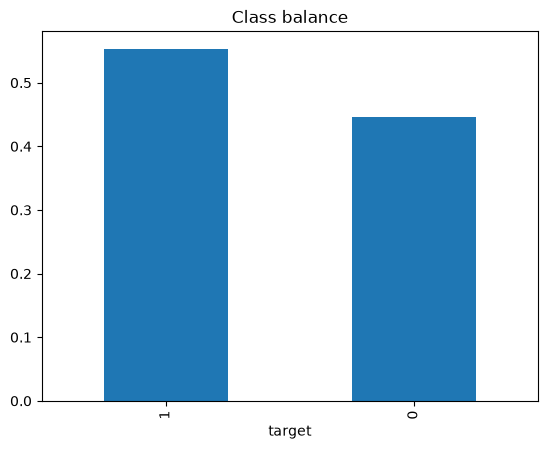

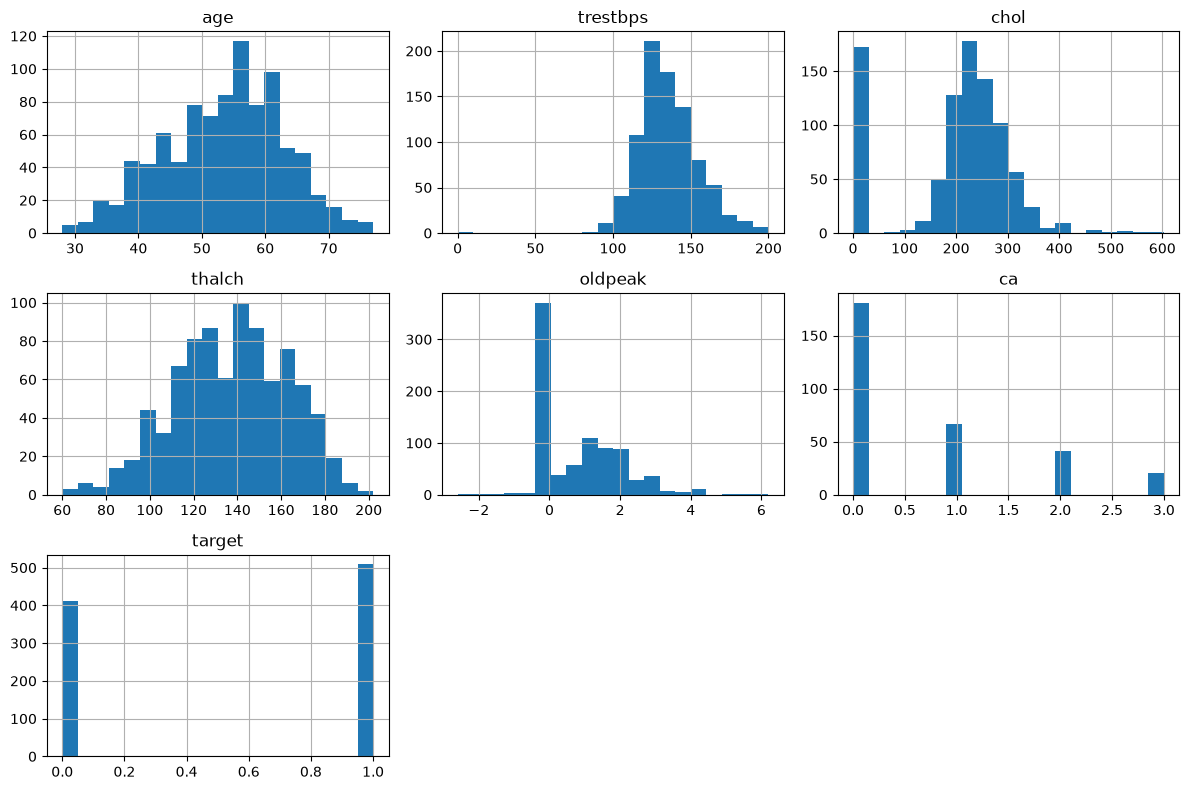

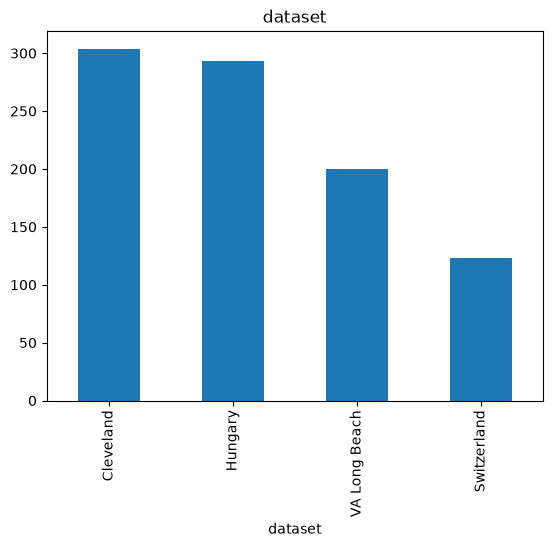

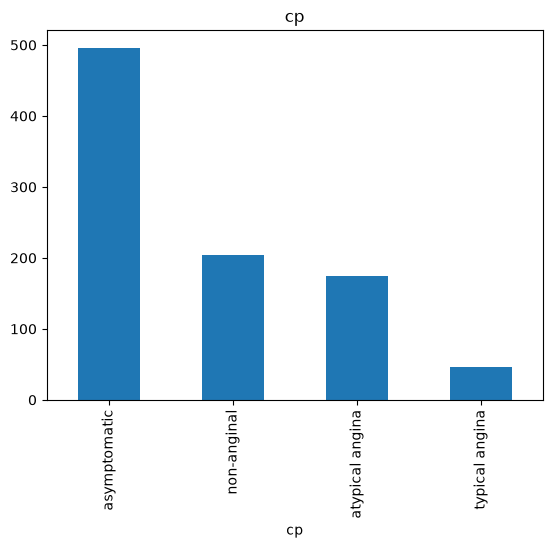

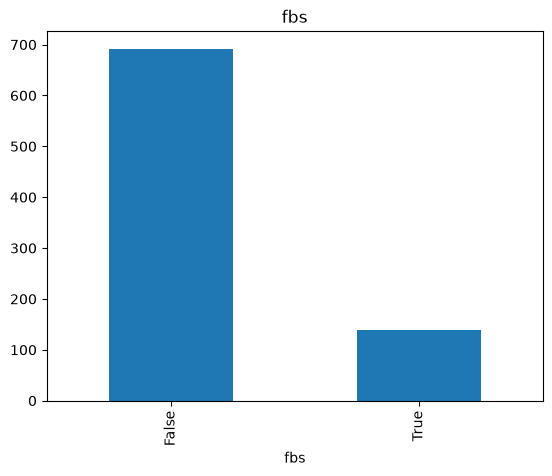

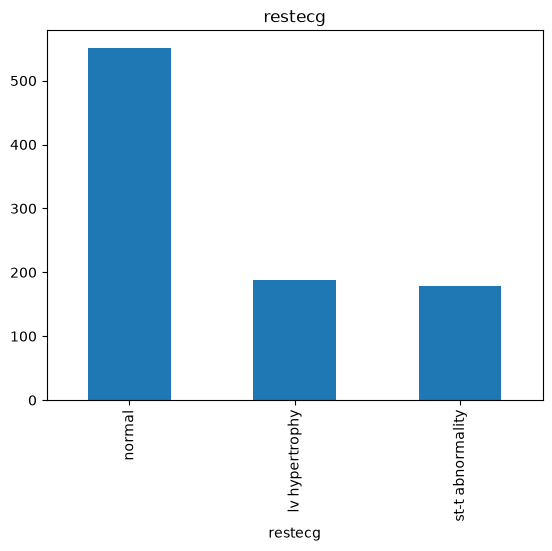

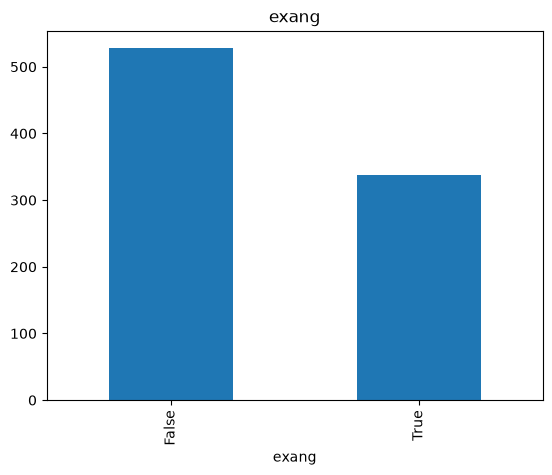

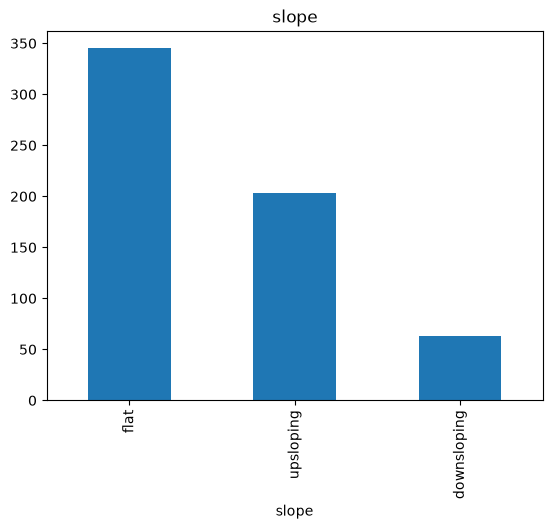

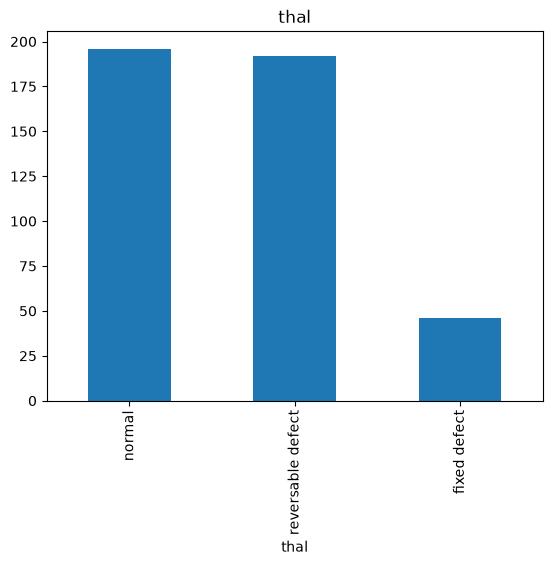

In [6]:
import matplotlib.pyplot as plt 

# 1. Missingness
missingness_by_site = df.groupby("dataset").apply(lambda g: g.isnull().mean().round(3))
print(missingness_by_site)

# 2. Class balance - target already exists in raw data (via 'num'). no cleaning needed
df["target"] = (df["num"] > 0).astype(int)
df["target"].value_counts(normalize=True).plot(kind="bar", title="Class balance")

# 3. Distributions of all numeric columns
numeric_cols = df.select_dtypes(include="number").columns.drop(["id", "num"])
(df[numeric_cols] == 0).sum()
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()

# 4. Distributions of all categorical columns
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col].value_counts().plot(kind="bar", title=col)
    plt.show()

For the variables ca and thal, large percentages of data corresponding to those variables are missing from the Hungary (98% = ca, 90.4% = thal), Switzerland (95.9% = ca), and VA Long Beach (99% = ca, 83% = thal) sites. Thus, this model focuses primarily on the data from the Cleveland site.